In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [19]:
df=pd.read_csv('marketing_campaign.csv',sep='\t')

In [20]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [21]:
df.isna().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64

In [22]:
numerical_features = df.select_dtypes(include=['int64', 'float64']).columns
df_num = df[numerical_features]

In [23]:
df_num = df_num.fillna(df_num.mean())

In [24]:
scaler=StandardScaler()
X_scaled=scaler.fit_transform(df_num)

In [25]:
pca=PCA()
X_pca=pca.fit_transform(X_scaled)

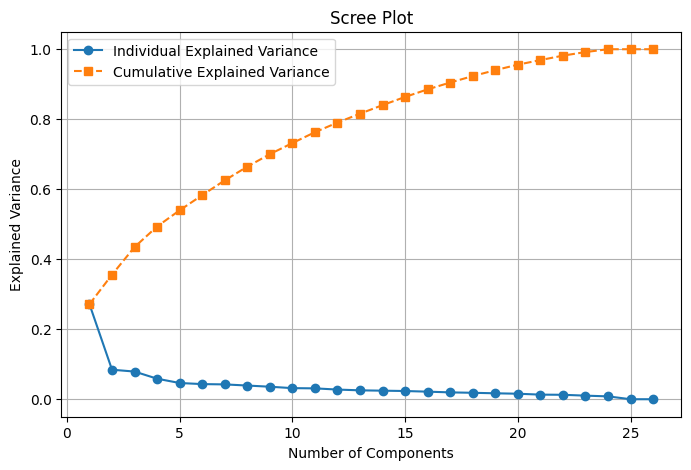

In [26]:
plt.figure(figsize=(8,5))

plt.plot(range(1, len(pca.explained_variance_ratio_) + 1),
         pca.explained_variance_ratio_,
         'o-', label='Individual Explained Variance')

plt.plot(range(1, len(pca.explained_variance_ratio_) + 1),
         np.cumsum(pca.explained_variance_ratio_),
         's--', label='Cumulative Explained Variance')

plt.xlabel("Number of Components")
plt.ylabel("Explained Variance")
plt.title("Scree Plot")
plt.legend()
plt.grid(True)
plt.show()

In [27]:
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)
n_components = np.argmax(cumulative_variance >= 0.90) + 1

print("Number of components for 90% variance:", n_components)

Number of components for 90% variance: 17


In [28]:
pca_final = PCA(n_components=n_components)
X_reduced = pca_final.fit_transform(X_scaled)

In [29]:
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f'PC{i+1}' for i in range(len(pca.components_))],
    index=df_num.columns
)

print("Top features contributing to PC1:")
print(loadings['PC1'].sort_values(ascending=False).head())

print("\nTop features contributing to PC2:")
print(loadings['PC2'].sort_values(ascending=False).head())

Top features contributing to PC1:
NumCatalogPurchases    0.318628
MntMeatProducts        0.312443
MntWines               0.306426
Income                 0.290892
NumStorePurchases      0.282799
Name: PC1, dtype: float64

Top features contributing to PC2:
Teenhome             0.540449
NumDealsPurchases    0.458994
NumWebPurchases      0.352781
NumStorePurchases    0.212635
NumWebVisitsMonth    0.160280
Name: PC2, dtype: float64


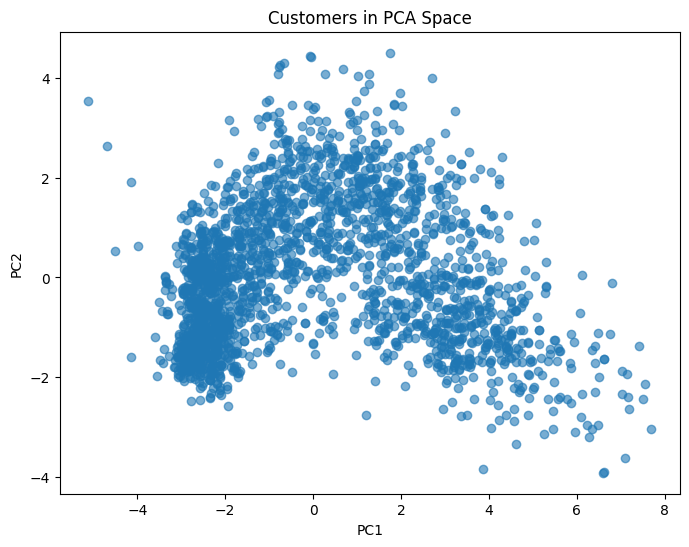

In [30]:
plt.figure(figsize=(8,6))
plt.scatter(X_reduced[:,0], X_reduced[:,1], alpha=0.6)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Customers in PCA Space")
plt.show()

In [31]:
start = time.time()

kmeans_original = KMeans(n_clusters=4, random_state=42)
labels_original = kmeans_original.fit_predict(X_scaled)

time_original = time.time() - start

sil_original = silhouette_score(X_scaled, labels_original)

In [32]:
start = time.time()

kmeans_pca = KMeans(n_clusters=4, random_state=42)
labels_pca = kmeans_pca.fit_predict(X_reduced)

time_pca = time.time() - start

sil_pca = silhouette_score(X_reduced, labels_pca)

In [33]:
print("Original Data:")
print("Silhouette Score:", sil_original)
print("Computation Time:", time_original)

print("\nPCA Reduced Data:")
print("Silhouette Score:", sil_pca)
print("Computation Time:", time_pca)

Original Data:
Silhouette Score: 0.17985246915340528
Computation Time: 5.876852989196777

PCA Reduced Data:
Silhouette Score: 0.11056969544439628
Computation Time: 0.03279280662536621
